# 11f — Event-study e pre-trends para todos os 18 outcomes (corrigido)

**Pré-registro v2.5 (em preparação) — bloco K sub-item (iii)**

Após descoberta inesperada no 11e (todas as culturas crescem em área nos tratados), precisamos validar **todos** os ATTs já estimados via teste de pre-trends. Se pre-trends ≠ 0 sig, ATTs positivos podem refletir tendência prévia (Hipótese B — confounding), não efeito causal do programa.

**18 outcomes em 4 grupos:**
- G1. Macro v2.3.7 (4): asinh_luc, asinh_carbono_solo, log1p_queima, log_solos_manejados
- G2. Decomposição B4.M.4 v2.4 (4): asinh_cana_direto, log1p_fert_n, log1p_calagem, log1p_res_outros
- G3. PAM substituição (4): pam_area_cana_t/soja_t/milho_t/algodao_t
- G4. MapBiomas (6): share_cana, pastagem, vegetacao_nativa, soja, silvicultura, urbano

**Estimador:** CS-DR com `aggregate("event")`. Spec: FULL2 (decisão v2.4). Horizonte: [-4, +6] anos.

**Pré-condições no Drive:**
- `pipeline/b4_event_studies.py` (este módulo)
- `pipeline/b4m4_decomposicao.py`, `pipeline/b4_substituicao_area.py`
- `data/interim/panel_canavieiro_main.csv`, `seeg_subcanais_panel.csv`,
  `pam_1612_long_2012_2024.parquet`, `07_mapbiomas_panel_balanced_2015_2024_CORRIGIDO.csv`
- `data/raw/psm_baseline/base_psm_integrada_raw.csv`

## Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

# Setup portável — resolve a raiz do repositório sem depender do Google Drive.
# Para executar a partir do Drive, defina antes: os.environ["RENOVABIO_BASE_DIR"] = "<caminho>"
# Para executar a partir do Drive, defina antes de rodar esta célula:
import os
import sys
from pathlib import Path

if os.environ.get("RENOVABIO_BASE_DIR"):
    BASE_DIR = Path(os.environ["RENOVABIO_BASE_DIR"]).expanduser().resolve()
else:
    BASE_DIR = Path.cwd().resolve()
    while not (BASE_DIR / "requirements.txt").exists() and BASE_DIR != BASE_DIR.parent:
        BASE_DIR = BASE_DIR.parent

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

Mounted at /content/drive


In [2]:
!pip install differences

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.6 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from differences import ATTgt
from pipeline.config import interim, out_pre
from pipeline import b4m4_decomposicao as b4m4
from pipeline import b4_substituicao_area as b4s
from pipeline import b4_event_studies as bes
import importlib
importlib.reload(b4m4); importlib.reload(b4s); importlib.reload(bes)

N_BOOT = 999
RANDOM_STATE = 42
print(f"setup OK | N_BOOT={N_BOOT}")
print(f"\n18 outcomes em 4 grupos:")
for grp, outs in bes.OUTCOMES_GRUPOS.items():
    print(f"  {grp}: {len(outs)} outcomes")

setup OK | N_BOOT=999

18 outcomes em 4 grupos:
  G1_macro_v237: 4 outcomes
  G2_decomposicao_B4M4: 4 outcomes
  G3_substituicao_PAM: 4 outcomes
  G4_substituicao_MAPB: 6 outcomes


## Hotfix — compatibilidade com `differences.aggregate("event")`

Esta célula corrige o bug identificado no diagnóstico: o retorno de `aggregate("event")` pode vir com índice `relative_period` e colunas em `MultiIndex`. A versão anterior do `_flatten_event_result` não convertia esse índice em coluna e acabava deslocando as variáveis. Esta célula faz monkey-patch do módulo `bes` para o notebook rodar corretamente mesmo antes de substituir o arquivo `pipeline/b4_event_studies.py` no Drive.

In [4]:
# HOTFIX 21/05/2026 — aggregate('event') com índice relative_period + colunas MultiIndex
import time
from typing import Iterable, Sequence
import numpy as np
import pandas as pd

def _clean_col_name(col) -> str:
    """Converte nomes simples ou MultiIndex tuple em string estável."""
    if isinstance(col, tuple):
        parts = [str(x).strip() for x in col if str(x).strip() not in ("", "None", "nan")]
        return "_".join(parts) if parts else ""
    return str(col).strip()


def _norm_name(name: str) -> str:
    return (
        str(name)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace(".", "_")
        .replace("-", "_")
        .replace("__", "_")
    )


def _first_existing(columns: Sequence[str], predicates: Iterable) -> str | None:
    for col in columns:
        n = _norm_name(col)
        if any(pred(n) for pred in predicates):
            return col
    return None


def _ensure_event_time(event_df: pd.DataFrame) -> pd.DataFrame:
    """
    Garante coluna canônica `event_time`.
    Aceita também `relative_period`, `period` ou variações.
    """
    df = event_df.copy()
    if "event_time" in df.columns:
        return df

    candidates = [
        c for c in df.columns
        if _norm_name(c) in {
            "relative_period",
            "event_time",
            "event",
            "period",
            "time",
            "att_g_t_event_time",
            "attgt_event_time",
        }
        or "relative_period" in _norm_name(c)
        or "event_time" in _norm_name(c)
    ]

    if candidates:
        df = df.rename(columns={candidates[0]: "event_time"})
        return df

    raise KeyError(
        "Não encontrei coluna de tempo do evento. "
        f"Colunas disponíveis: {list(df.columns)}"
    )


def _flatten_event_result(ev) -> pd.DataFrame:
    """
    Normaliza o retorno de `ATTgt.aggregate("event")` para colunas planas:

        event_time | ATT | SE | CI_lo | CI_hi | zero_not_in_cband

    A estrutura observada no diagnóstico foi:
    - index.name = 'relative_period'
    - columns = MultiIndex com:
      ('EventAggregation', '', 'ATT'),
      ('EventAggregation', 'analytic', 'std_error'),
      ('EventAggregation', 'pointwise conf. band', 'lower'),
      ('EventAggregation', 'pointwise conf. band', 'upper'),
      ('EventAggregation', 'pointwise conf. band', 'zero_not_in_cband')

    Esta função também tenta lidar com versões alternativas do pacote.
    """
    original_type = type(ev).__name__
    original_index = getattr(ev, "index", None)
    original_cols = None
    try:
        original_cols = list(ev.columns) if hasattr(ev, "columns") else None
    except Exception:
        original_cols = None

    try:
        # Series: normalmente índice = event_time e valor = ATT.
        if isinstance(ev, pd.Series):
            name = ev.name if ev.name is not None else "ATT"
            ev = ev.rename(name).reset_index()
            if ev.columns.size >= 2:
                ev = ev.rename(columns={ev.columns[0]: "event_time", ev.columns[1]: "ATT"})

        if not isinstance(ev, pd.DataFrame):
            raise TypeError(f"Objeto retornado não é DataFrame/Series: {type(ev).__name__}")

        ev = ev.copy()

        # O ponto crucial: quando index é relative_period, ele deve virar coluna.
        if not isinstance(ev.index, pd.RangeIndex) or ev.index.name is not None:
            ev = ev.reset_index()

        # Achatar colunas MultiIndex, inclusive a coluna criada por reset_index:
        # ('relative_period', '', '') -> 'relative_period'
        if isinstance(ev.columns, pd.MultiIndex):
            ev.columns = [_clean_col_name(c) for c in ev.columns]
        else:
            ev.columns = [_clean_col_name(c) for c in ev.columns]

        cols = list(ev.columns)

        # Identificação por nome.
        event_col = _first_existing(cols, [
            lambda n: n in {"relative_period", "event_time", "event", "period", "time"},
            lambda n: "relative_period" in n,
            lambda n: "event_time" in n,
        ])
        att_col = _first_existing(cols, [
            lambda n: n == "att",
            lambda n: n.endswith("_att"),
            lambda n: "eventaggregation_att" in n,
        ])
        se_col = _first_existing(cols, [
            lambda n: n in {"se", "std_error", "stderr", "std_err"},
            lambda n: "std_error" in n,
            lambda n: n.endswith("_se"),
        ])
        lo_col = _first_existing(cols, [
            lambda n: n in {"ci_lo", "lower", "lwr", "conf_low", "ci_lower"},
            lambda n: n.endswith("_lower"),
            lambda n: "conf_band_lower" in n,
        ])
        hi_col = _first_existing(cols, [
            lambda n: n in {"ci_hi", "upper", "upr", "conf_high", "ci_upper"},
            lambda n: n.endswith("_upper"),
            lambda n: "conf_band_upper" in n,
        ])
        sig_col = _first_existing(cols, [
            lambda n: "zero_not_in_cband" in n,
            lambda n: "zero_not" in n,
            lambda n: "signif" in n,
        ])

        # Fallback posicional, agora seguro porque o índice já foi resetado.
        # Esperado: event_time, ATT, SE, lower, upper, [flag]
        if event_col is None and len(cols) >= 1:
            event_col = cols[0]
        if att_col is None and len(cols) >= 2:
            att_col = cols[1]
        if se_col is None and len(cols) >= 3:
            se_col = cols[2]
        if lo_col is None and len(cols) >= 4:
            lo_col = cols[3]
        if hi_col is None and len(cols) >= 5:
            hi_col = cols[4]
        if sig_col is None and len(cols) >= 6:
            sig_col = cols[5]

        required = {
            "event_time": event_col,
            "ATT": att_col,
            "SE": se_col,
            "CI_lo": lo_col,
            "CI_hi": hi_col,
        }
        missing = [k for k, v in required.items() if v is None]
        if missing:
            raise KeyError(
                f"Não consegui identificar colunas obrigatórias: {missing}. "
                f"Colunas após flatten: {cols}"
            )

        out = pd.DataFrame({
            "event_time": pd.to_numeric(ev[event_col], errors="coerce"),
            "ATT": pd.to_numeric(ev[att_col], errors="coerce"),
            "SE": pd.to_numeric(ev[se_col], errors="coerce"),
            "CI_lo": pd.to_numeric(ev[lo_col], errors="coerce"),
            "CI_hi": pd.to_numeric(ev[hi_col], errors="coerce"),
        })

        if sig_col is not None and sig_col in ev.columns:
            out["zero_not_in_cband"] = ev[sig_col].astype(str).str.strip()
        else:
            out["zero_not_in_cband"] = np.where(
                (out["CI_lo"] > 0) | (out["CI_hi"] < 0),
                "*",
                "",
            )

        out = out.dropna(subset=["event_time"]).copy()
        if np.all(np.isclose(out["event_time"], np.round(out["event_time"]))):
            out["event_time"] = out["event_time"].astype(int)

        return out.sort_values("event_time").reset_index(drop=True)

    except Exception as e:
        print(f"    !!! _flatten_event_result falhou: {type(e).__name__}: {e}")
        print(f"    Formato original: type={original_type}")
        if original_index is not None:
            print(f"    Index original: name={getattr(original_index, 'name', None)!r}; "
                  f"type={type(original_index).__name__}")
        print(f"    Colunas originais: {original_cols}")
        raise


def _filter_event_window(ev: pd.DataFrame, event_window: tuple[int, int] | None) -> pd.DataFrame:
    """Filtra event_time dentro de uma janela inclusiva, se fornecida."""
    ev = _ensure_event_time(ev)
    if event_window is None:
        return ev
    lo, hi = event_window
    return ev[(ev["event_time"] >= lo) & (ev["event_time"] <= hi)].copy()


def run_event_study(
    panel_cs: pd.DataFrame,
    outcomes: list[str],
    covs: list[str],
    n_boot: int = 999,
    random_state: int = 42,
    cohort_col: str = "g_m_cs",
    spec_name: str = "FULL2",
    event_window: tuple[int, int] | None = (-4, 6),
) -> pd.DataFrame:
    """
    Roda CS-DR + aggregate("event") para cada outcome.

    Parameters
    ----------
    event_window:
        Janela inclusiva de períodos relativos a manter no resultado final.
        Use `(-4, 6)` para o horizonte do B4 ou `None` para manter tudo.
    """
    from differences import ATTgt

    rows = []
    t0 = time.time()

    for outcome in outcomes:
        if outcome not in panel_cs.columns:
            print(f">>> {outcome}: AUSENTE no painel, pulado")
            continue

        t_o = time.time()
        try:
            data = (
                panel_cs
                .dropna(subset=[outcome])
                .set_index(["geocode", "ano"])
                .sort_index()
            )

            n_munis = data.index.get_level_values("geocode").nunique()

            attgt = ATTgt(data=data, cohort_column=cohort_col)
            attgt.fit(
                formula=f"{outcome} ~ " + " + ".join(covs),
                est_method="dr",
                control_group="never_treated",
                boot_iterations=n_boot,
                random_state=random_state,
                progress_bar=False,
                n_jobs=1,
            )

            ev_raw = attgt.aggregate("event")
            ev = _flatten_event_result(ev_raw)
            ev = _filter_event_window(ev, event_window)
            ev["outcome"] = outcome
            ev["spec"] = spec_name
            ev["n_munis"] = n_munis
            rows.append(ev)

            if ev.empty:
                msg_periods = "0 períodos após filtro"
            else:
                msg_periods = f"{ev.shape[0]} períodos t=[{ev['event_time'].min()}, {ev['event_time'].max()}]"

            print(
                f"  OK {outcome:38s} [{time.time() - t_o:.1f}s]  "
                f"{msg_periods}"
            )

        except Exception as e:
            print(f"  XX {outcome:38s} {type(e).__name__}: {str(e)[:140]}")

    if not rows:
        return pd.DataFrame()

    df = pd.concat(rows, ignore_index=True, sort=False)
    print(f"\nOK event-study: {time.time() - t0:.1f}s total, {df.shape[0]} linhas")
    return df


def _pretrend_mask(event_time: pd.Series, pre_periods) -> pd.Series:
    """
    Seleciona períodos de pré-tendência.
    - tuple/list de tamanho 2, ex. (-4, -2): janela inclusiva.
    - lista maior, ex. [-4, -3, -2]: períodos explícitos.
    """
    if pre_periods is None:
        return event_time < 0

    periods = list(pre_periods)
    if len(periods) == 2:
        lo, hi = min(periods), max(periods)
        return (event_time >= lo) & (event_time <= hi)

    return event_time.isin(periods)


def _is_sig_from_ci_or_z(row) -> bool:
    """Significância individual: prioriza IC; fallback para |z| > 1.96."""
    lo = row.get("CI_lo", np.nan)
    hi = row.get("CI_hi", np.nan)
    if pd.notna(lo) and pd.notna(hi):
        return bool((lo > 0) or (hi < 0))

    att = row.get("ATT", np.nan)
    se = row.get("SE", np.nan)
    return bool(pd.notna(att) and pd.notna(se) and se > 0 and abs(att / se) > 1.959963985)


def test_pretrends(
    event_df: pd.DataFrame,
    pre_periods: tuple[int, int] | list[int] = (-4, -2),
) -> pd.DataFrame:
    """
    Teste aproximado de pre-trends por outcome.

    Para cada outcome:
    - conta quantos períodos pré são individualmente significativos;
    - calcula Wald aproximado = soma((ATT/SE)^2);
    - calcula p-valor chi-quadrado aproximado com df = número de períodos.

    Observação: este NÃO é o teste conjunto exato com matriz de covariância
    completa. É uma triagem diagnóstica útil para flagar outcomes suspeitos.
    """
    from scipy.stats import chi2

    event_df = _ensure_event_time(event_df)

    results = []
    for outcome in event_df["outcome"].dropna().unique():
        sub = event_df[event_df["outcome"] == outcome].copy()
        sub_pre = sub[_pretrend_mask(sub["event_time"], pre_periods)].copy()
        sub_pre = sub_pre.dropna(subset=["ATT", "SE"])
        sub_pre = sub_pre[sub_pre["SE"] > 0].copy()

        if sub_pre.empty:
            results.append({
                "outcome": outcome,
                "pre_periods": str(pre_periods),
                "n_pre_periods": 0,
                "n_pre_sig_individual": 0,
                "wald_stat_approx": np.nan,
                "p_value_approx": np.nan,
                "pretrend_flag": "NO_DATA",
            })
            continue

        z_vals = sub_pre["ATT"] / sub_pre["SE"]
        n_pre = int(len(sub_pre))
        n_sig_ind = int(sub_pre.apply(_is_sig_from_ci_or_z, axis=1).sum())
        wald = float((z_vals ** 2).sum())
        pval = float(1 - chi2.cdf(wald, df=n_pre))

        if n_sig_ind == 0 and pval > 0.10:
            flag = "PRE_TRENDS_PLANOS"
        elif n_sig_ind == 0 and pval > 0.05:
            flag = "PRE_TRENDS_MARGINAIS"
        elif n_sig_ind >= 1 or pval <= 0.05:
            flag = "PRE_TRENDS_VIOLADOS"
        else:
            flag = "INDETERMINADO"

        results.append({
            "outcome": outcome,
            "pre_periods": str(pre_periods),
            "n_pre_periods": n_pre,
            "n_pre_sig_individual": n_sig_ind,
            "wald_stat_approx": wald,
            "p_value_approx": pval,
            "pretrend_flag": flag,
        })

    return pd.DataFrame(results)


def assess_event_studies(
    event_df: pd.DataFrame,
    pretrend_df: pd.DataFrame,
    horizons: Sequence[int] = (-2, 0, 1, 3, 5),
) -> pd.DataFrame:
    """
    Síntese compacta por outcome: ATT em horizontes selecionados + flag de
    pre-trend + classificação editorial.
    """
    event_df = _ensure_event_time(event_df)

    rows = []
    for outcome in event_df["outcome"].dropna().unique():
        sub = event_df[event_df["outcome"] == outcome].copy()
        pre = (
            pretrend_df[pretrend_df["outcome"] == outcome].iloc[0]
            if (pretrend_df["outcome"] == outcome).any()
            else None
        )

        def get_att(t: int):
            x = sub[sub["event_time"] == t]
            if x.empty or pd.isna(x.iloc[0]["ATT"]):
                return np.nan, np.nan, False
            row = x.iloc[0]
            att = float(row["ATT"])
            se = float(row["SE"]) if pd.notna(row["SE"]) else np.nan
            sig = _is_sig_from_ci_or_z(row)
            return att, se, sig

        row = {"outcome": outcome}

        for t in horizons:
            att, se, sig = get_att(int(t))
            row[f"att_t{int(t):+d}"] = att
            row[f"se_t{int(t):+d}"] = se
            row[f"sig_t{int(t):+d}"] = sig

        row["pretrend_flag"] = pre["pretrend_flag"] if pre is not None else "NA"
        row["pretrend_wald_p"] = pre["p_value_approx"] if pre is not None else np.nan

        post_sig = any(
            row.get(f"sig_t{int(t):+d}", False)
            for t in horizons
            if int(t) >= 0
        )

        if row["pretrend_flag"] == "PRE_TRENDS_PLANOS" and post_sig:
            row["veredito"] = "ATT_ROBUSTO"
        elif row["pretrend_flag"] == "PRE_TRENDS_PLANOS" and not post_sig:
            row["veredito"] = "NULO_LIMPO"
        elif row["pretrend_flag"] == "PRE_TRENDS_VIOLADOS":
            row["veredito"] = "ATT_SUSPEITO_VIES"
        elif row["pretrend_flag"] == "PRE_TRENDS_MARGINAIS":
            row["veredito"] = "ATT_CAUTELOSO"
        else:
            row["veredito"] = "INSPECAO_MANUAL"

        rows.append(row)

    return pd.DataFrame(rows)


# Aplicar hotfix ao módulo importado como `bes`
bes._flatten_event_result = _flatten_event_result
bes._ensure_event_time = _ensure_event_time
bes._filter_event_window = _filter_event_window
bes.run_event_study = run_event_study
bes.test_pretrends = test_pretrends
bes.assess_event_studies = assess_event_studies

print("Hotfix OK: b4_event_studies agora lida com relative_period/MultiIndex e filtra event_window.")


Hotfix OK: b4_event_studies agora lida com relative_period/MultiIndex e filtra event_window.


## Bloco 1 — Reconstruir painel CS completo (espelha 11d + 11e)

Carrega painel canônico, dropa 6 covs colidentes, join sub-canais SEEG + PAM temporal + MapBiomas, aplica transformações, reconstrói 52 covs, monta painel CS com NaN never-treated.

In [5]:
panel = pd.read_csv(interim("panel_canavieiro_main.csv"), dtype={"geocode": str})
COVS_COLIDENTES = ["gini","densidade_pop","log_pop","idhm_renda",
                   "ivs_capital_humano","ivs_renda_trabalho"]
panel = panel.drop(columns=[c for c in COVS_COLIDENTES if c in panel.columns])
assert panel["geocode"].nunique() == 842
print(f"painel base: {panel.shape}")

# Join sub-canais SEEG (cana_direto)
seeg_sub = pd.read_csv(interim("seeg_subcanais_panel.csv"))
panel = b4m4.join_subchannels(panel, seeg_sub)
print(f"apos seeg sub-canais: {panel.shape}")

painel base: (8420, 133)
  join: 842 munis no painel canônico, 842 com cana_direto computado
apos seeg sub-canais: (8420, 149)


In [6]:
# Join PAM temporal (4 culturas)
pam_long = pd.read_parquet(interim("pam_1612_long_2012_2024.parquet"))
panel = b4s.join_pam_areas_temporal(panel, pam_long)

# Join MapBiomas shares
mapb = pd.read_csv(interim("07_mapbiomas_panel_balanced_2015_2024_CORRIGIDO.csv"),
                   dtype={"geocode": str})
panel = b4s.join_mapbiomas_shares(panel, mapb)

# Aplicar transformações (PAM + MapBiomas; seeg sub-canais já transformados)
panel = b4s.apply_transformations(panel)
print(f"\npainel apos todos os joins: {panel.shape}")

# Verificar presença dos 18 outcomes
todos_outcomes = sum(bes.OUTCOMES_GRUPOS.values(), [])
print(f"\nCobertura dos 18 outcomes:")
for o in todos_outcomes:
    if o in panel.columns:
        nn = panel[o].notna().sum()
        print(f"  OK {o:38s} notna={nn}")
    else:
        print(f"  XX {o:38s} *** AUSENTE ***")

  dropadas (eram constantes intra-municipio): ['pam_area_cana', 'pam_area_soja', 'pam_area_milho']
  PAM joinada como série temporal:
    pam_area_cana_t       : 832/842 munis variam temporalmente, 208 celulas == 0
    pam_area_soja_t       : 782/842 munis variam temporalmente, 1450 celulas == 0
    pam_area_milho_t      : 836/842 munis variam temporalmente, 202 celulas == 0
    pam_area_algodao_t    : 111/842 munis variam temporalmente, 7865 celulas == 0
  mapbiomas: 842 munis no painel canonico, 842 com shares casados

painel apos todos os joins: (8420, 166)

Cobertura dos 18 outcomes:
  OK asinh_luc                              notna=8420
  OK asinh_carbono_solo                     notna=8420
  OK log1p_queima                           notna=8420
  OK log_solos_manejados                    notna=8410
  OK asinh_cana_direto                      notna=8420
  OK log1p_fert_n                           notna=8420
  OK log1p_calagem                          notna=8420
  OK log1p_res_outro

## Bloco 2 — Reconstruir covariáveis e painel CS

In [7]:
psm_raw = pd.read_csv(
    BASE_DIR / "data/raw/psm_baseline/base_psm_integrada_raw.csv",
    low_memory=False,
)
psm_raw["geocode"] = psm_raw["0_cd_ibge"].astype(str).str.zfill(7)

muni_id = (panel.groupby("geocode", as_index=False)
           .agg(municipio=("municipio","first"), uf=("uf","first"),
                is_treated_ever=("is_treated_ever","first"),
                g_m=("g_m","first"), bioma=("bioma","first")))
muni_id["treated"] = muni_id["is_treated_ever"].astype(int)
df_cs = muni_id.merge(psm_raw, on="geocode", how="inner")
print(f"df_cs: {df_cs.shape}")

df_cs: (842, 172)


In [8]:
def safe_log1p(s, idx):
    s = pd.to_numeric(s, errors="coerce") if s is not None else pd.Series(np.nan, index=idx)
    return np.log1p(s.clip(lower=0))
def safe_div(num, den, idx):
    num = pd.to_numeric(num, errors="coerce") if num is not None else pd.Series(np.nan, index=idx)
    den = pd.to_numeric(den, errors="coerce") if den is not None else pd.Series(np.nan, index=idx)
    return np.where((den.notna()) & (den > 0), num / den, np.nan)
def asn(s, idx):
    return pd.to_numeric(s, errors="coerce") if s is not None else pd.Series(np.nan, index=idx)

def build_covariates_raw(df):
    d = df.copy(); idx = d.index
    d["log_pib_total"]=safe_log1p(d.get("1_pib_total"),idx)
    d["log_pib_pc"]=safe_log1p(d.get("1_pib_percap"),idx)
    d["log_pop"]=safe_log1p(d.get("2_pop_2017_ibge"),idx)
    d["log_area_total"]=safe_log1p(d.get("14_area_total"),idx)
    d["densidade_pop"]=safe_div(d.get("2_pop_2017_ibge"),d.get("14_area_total"),idx)
    d["share_vadc_agro"]=safe_div(d.get("1_vadc_agro"),d.get("1_vadc_bruto"),idx)
    d["share_vadc_ind"]=safe_div(d.get("1_vadc_ind"),d.get("1_vadc_bruto"),idx)
    d["share_vadc_serv"]=safe_div(d.get("1_vadc_serv"),d.get("1_vadc_bruto"),idx)
    d["share_vadc_adm"]=safe_div(d.get("1_vadc_adm"),d.get("1_vadc_bruto"),idx)
    d["share_cana_baseline"]=asn(d.get("3_mb_sharegrp_pre_cana"),idx)
    d["mb_share_soja"]=asn(d.get("3_mb_sharegrp_pre_soja"),idx)
    d["mb_share_pastagem"]=asn(d.get("3_mb_sharegrp_pre_pastagem"),idx)
    d["mb_share_vegetacao_nativa"]=asn(d.get("3_mb_sharegrp_pre_vegetacao_nativa"),idx)
    d["mb_share_urbano"]=asn(d.get("3_mb_sharegrp_pre_urbano_infra"),idx)
    d["log_area_cana"]=safe_log1p(d.get("4_area_colhida_ha_cana"),idx)
    d["log_area_soja"]=safe_log1p(d.get("4_area_colhida_ha_soja"),idx)
    d["log_area_agri_total"]=safe_log1p(d.get("4_area_colhida_ha"),idx)
    d["share_area_cana_agri"]=safe_div(d.get("4_area_colhida_ha_cana"),d.get("4_area_colhida_ha"),idx)
    d["share_est_af"]=safe_div(d.get("5_num_est_af"),d.get("5_num_est_total"),idx)
    d["share_est_mp"]=safe_div(d.get("5_num_est_mp"),d.get("5_num_est_total"),idx)
    d["share_area_af"]=safe_div(d.get("6_area_lav_af"),d.get("6_area_lav_total"),idx)
    d["share_area_mp"]=safe_div(d.get("6_area_lav_mp"),d.get("6_area_lav_total"),idx)
    d["trator_per_est"]=safe_div(d.get("11_num_trator_total"),d.get("5_num_est_total"),idx)
    d["share_est_irrig"]=safe_div(d.get("12_num_est_irrig_total"),d.get("5_num_est_total"),idx)
    d["share_area_irrig"]=safe_div(d.get("12_area_irrig_total"),d.get("6_area_lav_total"),idx)
    d["share_est_fin_total"]=safe_div(d.get("13_num_est_fin_total"),d.get("5_num_est_total"),idx)
    d["share_est_at"]=safe_div(d.get("10_num_est_receb_at"),d.get("5_num_est_total"),idx)
    d["natveg_share_area"]=safe_div(d.get("14_vegetacao_natural"),d.get("14_area_total"),idx)
    d["desmat_share_area"]=safe_div(d.get("14_desmatado"),d.get("14_area_total"),idx)
    d["idhm_renda"]=asn(d.get("17_idhm_renda"),idx); d["idhm_educ"]=asn(d.get("17_idhm_educ"),idx)
    d["ivs_infra"]=asn(d.get("17_ivs_infraestrutura_urbana"),idx); d["gini"]=asn(d.get("17_i_gini"),idx)
    d["idhm_long"]=asn(d.get("17_idhm_long"),idx); d["ivs_capital_humano"]=asn(d.get("17_ivs_capital_humano"),idx)
    d["ivs_renda_trabalho"]=asn(d.get("17_ivs_renda_e_trabalho"),idx)
    d["share_est_at_coop"]=safe_div(d.get("10_num_est_receb_at_coop"),d.get("5_num_est_total"),idx)
    d["share_est_at_gov"]=safe_div(d.get("10_num_est_receb_at_gov"),d.get("5_num_est_total"),idx)
    d["share_fin_invest"]=safe_div(d.get("13_num_est_fin_invest"),d.get("5_num_est_total"),idx)
    d["share_fin_cust"]=safe_div(d.get("13_num_est_fin_cust"),d.get("5_num_est_total"),idx)
    d["share_est_trator"]=safe_div(d.get("11_num_est_trator_total"),d.get("5_num_est_total"),idx)
    d["share_est_irrig_pivo"]=safe_div(d.get("12_num_est_irrig_pivo"),d.get("5_num_est_total"),idx)
    d["pct_est_energia"]=asn(d.get("7_est_com_energia%"),idx)
    d["log_area_milho"]=safe_log1p(d.get("4_area_colhida_ha_milho"),idx)
    d["log_area_alg"]=safe_log1p(d.get("4_area_colhida_ha_alg"),idx)
    d["log_area_cafarab"]=safe_log1p(d.get("4_area_colhida_ha_cafarab"),idx)
    d["log_area_cafcan"]=safe_log1p(d.get("4_area_colhida_ha_cafcan"),idx)
    d["mb_share_cafe"]=asn(d.get("3_mb_sharegrp_pre_cafe"),idx)
    d["mb_share_algodao"]=asn(d.get("3_mb_sharegrp_pre_algodao"),idx)
    d["mb_share_silvicultura"]=asn(d.get("3_mb_sharegrp_pre_silvicultura"),idx)
    d["mb_share_agua"]=asn(d.get("3_mb_sharegrp_pre_agua"),idx)
    d["mb_share_outros"]=asn(d.get("3_mb_sharegrp_pre_outros"),idx)
    d["mb_share_agri_total"]=asn(d.get("3_mb_sharegrp_pre_agricultura_total"),idx)
    d["share_num_est_mp"]=safe_div(d.get("5_num_est_mp"),d.get("5_num_est_total"),idx)
    d["share_est_pec"]=safe_div(d.get("5_num_est_pec_total"),d.get("5_num_est_total"),idx)
    d["share_est_lavperm"]=safe_div(d.get("5_num_est_lavperm_total"),d.get("5_num_est_total"),idx)
    d["share_est_lavtemp"]=safe_div(d.get("5_num_est_lavtemp_total"),d.get("5_num_est_total"),idx)
    d["share_area_lavperm"]=safe_div(d.get("6_area_lavperm_total"),d.get("6_area_lav_total"),idx)
    d["share_area_lavtemp"]=safe_div(d.get("6_area_lavtemp_total"),d.get("6_area_lav_total"),idx)
    d["share_area_pec"]=safe_div(d.get("6_area_pec_total"),d.get("6_area_lav_total"),idx)
    d["share_fin_comer"]=safe_div(d.get("13_num_est_fin_comer"),d.get("5_num_est_total"),idx)
    d["share_est_at_propr"]=safe_div(d.get("10_num_est_receb_at_propr"),d.get("5_num_est_total"),idx)
    d["share_est_at_gov_out"]=safe_div(d.get("10_num_est_receb_at_gov_out"),d.get("5_num_est_total"),idx)
    share_cols = [c for c in d.columns if ("share" in c) or c.startswith("mb_share_")]
    for c in share_cols:
        s = pd.to_numeric(d[c], errors="coerce")
        if not s.dropna().empty and (s.dropna().between(-0.05,1.05).mean() > 0.8):
            d[c] = s.clip(0,1)
    return d

df_cs = build_covariates_raw(df_cs)

# Definir FULL2 (spec principal v2.4)
COVS_LEAN = ["log_pib_total","log_pib_pc","log_pop","densidade_pop",
             "share_vadc_agro","share_vadc_ind","share_vadc_serv",
             "share_cana_baseline","mb_share_soja","mb_share_pastagem","mb_share_vegetacao_nativa",
             "log_area_cana","log_area_soja","share_area_cana_agri",
             "share_est_af","share_area_af","trator_per_est","share_est_irrig","share_est_fin_total",
             "ivs_infra","gini"]
COVS_FULL = COVS_LEAN + ["share_vadc_adm","idhm_educ","idhm_renda","idhm_long",
                          "ivs_capital_humano","ivs_renda_trabalho",
                          "share_est_at","share_est_at_coop","share_est_at_gov",
                          "share_fin_invest","share_fin_cust",
                          "share_est_trator","share_est_irrig_pivo","pct_est_energia"]
COVS_FULL2 = [c for c in COVS_FULL if c not in ("share_vadc_agro","share_vadc_ind")]

all_covs = sorted(set(COVS_FULL2))
for c in all_covs:
    if df_cs[c].isna().any():
        df_cs[c] = df_cs.groupby("uf")[c].transform(lambda x: x.fillna(x.median()))
        df_cs[c] = df_cs[c].fillna(df_cs[c].median())
assert df_cs[all_covs].isna().sum().sum() == 0
print(f"OK FULL2: {len(COVS_FULL2)} covs imputadas")

OK FULL2: 33 covs imputadas


In [9]:
panel_cs = panel.merge(df_cs[["geocode"] + all_covs], on="geocode", how="left")
panel_cs["g_m_cs"] = panel_cs["g_m"]
n_treated = panel_cs["g_m_cs"].notna().sum() // 10
n_never = panel_cs["g_m_cs"].isna().sum() // 10
assert n_treated == 194 and n_never == 648
print(f"OK painel CS: 194 tratados, 648 nunca-tratados")

OK painel CS: 194 tratados, 648 nunca-tratados


## Bloco 3 — Event-study para os 18 outcomes (sob FULL2)

Tempo esperado: ~30 min total (18 outcomes × ~90s cada com 999 boot).

In [10]:
todos_outcomes = sum(bes.OUTCOMES_GRUPOS.values(), [])
EVENT_WINDOW = (-4, 6)

print(f"Rodando event-study para {len(todos_outcomes)} outcomes sob FULL2...")
print(f"Janela reportada: t={EVENT_WINDOW[0]} a t={EVENT_WINDOW[1]}")
print(f"Tempo esperado: ~30 min\n")

# A versão corrigida de bes.run_event_study aceita event_window.
# O try/except mantém compatibilidade caso você rode com um módulo antigo sem esse argumento.
try:
    ev_df = bes.run_event_study(
        panel_cs, outcomes=todos_outcomes, covs=COVS_FULL2,
        n_boot=N_BOOT, random_state=RANDOM_STATE,
        spec_name="FULL2", event_window=EVENT_WINDOW,
    )
except TypeError:
    ev_df = bes.run_event_study(
        panel_cs, outcomes=todos_outcomes, covs=COVS_FULL2,
        n_boot=N_BOOT, random_state=RANDOM_STATE,
        spec_name="FULL2",
    )
    ev_df = ev_df[(ev_df["event_time"] >= EVENT_WINDOW[0]) &
                  (ev_df["event_time"] <= EVENT_WINDOW[1])].copy()

# Sanidade mínima: ATT não pode ter virado event_time por engano.
assert "event_time" in ev_df.columns, "Coluna event_time ausente — verificar flatten."
assert "ATT" in ev_df.columns, "Coluna ATT ausente — verificar flatten."
assert ev_df["event_time"].between(EVENT_WINDOW[0], EVENT_WINDOW[1]).all(), "Event window fora do esperado."

ev_df.to_csv(interim("event_study_consolidado.csv"), index=False)
print(f"\nOK event_study_consolidado.csv {ev_df.shape}")

Rodando event-study para 18 outcomes sob FULL2...
Janela reportada: t=-4 a t=6
Tempo esperado: ~30 min

  OK asinh_luc                              [1.9s]  10 períodos t=[-4, 5]
  OK asinh_carbono_solo                     [1.4s]  10 períodos t=[-4, 5]
  OK log1p_queima                           [1.4s]  10 períodos t=[-4, 5]
  OK log_solos_manejados                    [1.4s]  10 períodos t=[-4, 5]
  OK asinh_cana_direto                      [1.7s]  10 períodos t=[-4, 5]
  OK log1p_fert_n                           [3.4s]  10 períodos t=[-4, 5]
  OK log1p_calagem                          [1.4s]  10 períodos t=[-4, 5]
  OK log1p_res_outros                       [1.4s]  10 períodos t=[-4, 5]
  OK log1p_pam_area_cana_t                  [1.4s]  10 períodos t=[-4, 5]
  OK asinh_pam_area_soja_t                  [1.4s]  10 períodos t=[-4, 5]
  OK asinh_pam_area_milho_t                 [1.5s]  10 períodos t=[-4, 5]
  OK asinh_pam_area_algodao_t               [1.4s]  10 períodos t=[-4, 5]
  OK log

## Bloco 4 — Teste de pre-trends por outcome

In [11]:
pre_df = bes.test_pretrends(ev_df, pre_periods=(-4, -2))
pre_df.to_csv(interim("pretrend_test_consolidado.csv"), index=False)

print("="*88)
print("TESTE DE PRE-TRENDS (Wald approx sobre periodos -4 a -2)")
print("="*88)
print(f"{'outcome':<40}{'n_pre':>7}{'n_sig':>7}{'wald':>10}{'p-val':>10}  flag")
print("-"*88)
for _, row in pre_df.iterrows():
    print(f"{row['outcome']:<40}{row['n_pre_periods']:>7}{row['n_pre_sig_individual']:>7}"
          f"{row['wald_stat_approx']:>10.2f}{row['p_value_approx']:>10.4f}  {row['pretrend_flag']}")

TESTE DE PRE-TRENDS (Wald approx sobre periodos -4 a -2)
outcome                                   n_pre  n_sig      wald     p-val  flag
----------------------------------------------------------------------------------------
asinh_luc                                     3      0      0.92    0.8209  PRE_TRENDS_PLANOS
asinh_carbono_solo                            3      0      2.24    0.5247  PRE_TRENDS_PLANOS
log1p_queima                                  3      1      4.86    0.1824  PRE_TRENDS_VIOLADOS
log_solos_manejados                           3      0      3.40    0.3345  PRE_TRENDS_PLANOS
asinh_cana_direto                             3      1      5.11    0.1637  PRE_TRENDS_VIOLADOS
log1p_fert_n                                  3      0      4.44    0.2174  PRE_TRENDS_PLANOS
log1p_calagem                                 3      0      3.33    0.3433  PRE_TRENDS_PLANOS
log1p_res_outros                              3      0      3.57    0.3117  PRE_TRENDS_PLANOS
log1p_pam_area_ca

## Bloco 5 — Síntese editorial: ATT por horizonte × veredito

In [12]:
syn = bes.assess_event_studies(ev_df, pre_df)
syn.to_csv(interim("event_study_resumo.csv"), index=False)

print("="*114)
print("SINTESE EDITORIAL: ATT em t=0,+1,+3,+5 + pre-trend + veredito")
print("="*114)
print(f"{'outcome':<40}{'t=0':>10}{'t=+1':>10}{'t=+3':>10}{'t=+5':>10}{'pretrend':>22}{'veredito':>22}")
print("-"*114)
for _, r in syn.iterrows():
    def fmt(att, sig):
        if pd.isna(att): return "  ---"
        return f"{att:+.3f}{'*' if sig else ' '}"
    print(f"{r['outcome']:<40}"
          f"{fmt(r['att_t+0'], r['sig_t+0']):>10}"
          f"{fmt(r['att_t+1'], r['sig_t+1']):>10}"
          f"{fmt(r['att_t+3'], r['sig_t+3']):>10}"
          f"{fmt(r['att_t+5'], r['sig_t+5']):>10}"
          f"{r['pretrend_flag']:>22}"
          f"{r['veredito']:>22}")
print("(*) sig 5% bicaudal")

SINTESE EDITORIAL: ATT em t=0,+1,+3,+5 + pre-trend + veredito
outcome                                        t=0      t=+1      t=+3      t=+5              pretrend              veredito
------------------------------------------------------------------------------------------------------------------
asinh_luc                                  -0.027    +0.038    -0.017    -0.215      PRE_TRENDS_PLANOS            NULO_LIMPO
asinh_carbono_solo                         -0.029    +0.047    +0.010    -0.018      PRE_TRENDS_PLANOS            NULO_LIMPO
log1p_queima                               +0.018    +0.127    +0.187    +0.079    PRE_TRENDS_VIOLADOS     ATT_SUSPEITO_VIES
log_solos_manejados                        +0.024    +0.042*   +0.068*   +0.042      PRE_TRENDS_PLANOS           ATT_ROBUSTO
asinh_cana_direto                          +0.069*   +0.107*   +0.337    +0.003    PRE_TRENDS_VIOLADOS     ATT_SUSPEITO_VIES
log1p_fert_n                               +0.044    +0.080*   +0.163*   

## Bloco 6 — Diagnóstico por grupo

In [13]:
print("="*70)
print("DIAGNOSTICO POR GRUPO DE OUTCOMES")
print("="*70)
for grp, outs in bes.OUTCOMES_GRUPOS.items():
    sub = syn[syn["outcome"].isin(outs)]
    n_total = len(sub)
    n_robusto = (sub["veredito"] == "ATT_ROBUSTO").sum()
    n_suspeito = (sub["veredito"] == "ATT_SUSPEITO_VIES").sum()
    n_cauteloso = (sub["veredito"] == "ATT_CAUTELOSO").sum()
    n_nulo = (sub["veredito"] == "NULO_LIMPO").sum()
    print(f"\n{grp}:")
    print(f"  total: {n_total}")
    print(f"  ATT_ROBUSTO      : {n_robusto}")
    print(f"  ATT_CAUTELOSO    : {n_cauteloso}")
    print(f"  ATT_SUSPEITO_VIES: {n_suspeito}  <-- pre-trends violados")
    print(f"  NULO_LIMPO       : {n_nulo}")

DIAGNOSTICO POR GRUPO DE OUTCOMES

G1_macro_v237:
  total: 4
  ATT_ROBUSTO      : 1
  ATT_CAUTELOSO    : 0
  ATT_SUSPEITO_VIES: 1  <-- pre-trends violados
  NULO_LIMPO       : 2

G2_decomposicao_B4M4:
  total: 4
  ATT_ROBUSTO      : 3
  ATT_CAUTELOSO    : 0
  ATT_SUSPEITO_VIES: 1  <-- pre-trends violados
  NULO_LIMPO       : 0

G3_substituicao_PAM:
  total: 4
  ATT_ROBUSTO      : 2
  ATT_CAUTELOSO    : 0
  ATT_SUSPEITO_VIES: 0  <-- pre-trends violados
  NULO_LIMPO       : 2

G4_substituicao_MAPB:
  total: 6
  ATT_ROBUSTO      : 1
  ATT_CAUTELOSO    : 0
  ATT_SUSPEITO_VIES: 0  <-- pre-trends violados
  NULO_LIMPO       : 5


## Conclusão B4 event-study corrigido

Saídas:
- `event_study_consolidado.csv` — 18 outcomes × ~11 períodos cada (estimativas pontuais + CI)
- `pretrend_test_consolidado.csv` — teste Wald aproximado de pre-trends por outcome
- `event_study_resumo.csv` — síntese ATT(t=0/+1/+3/+5) + veredito por outcome

**Interpretação:**
- **ATT_ROBUSTO**: pre-trends planos + ATT pós sig — efeito causal limpo
- **ATT_CAUTELOSO**: pre-trends marginais — reportar com nota de robustez
- **ATT_SUSPEITO_VIES**: pre-trends violados — viés de seleção provável (Hipótese B!)
- **NULO_LIMPO**: pre-trends planos + ATT pós nulo — controle válido sem efeito

**Próximo passo:** revisar a v2.5 do pré-registro com base nos vereditos. Se G3+G4 (PAM+MapBiomas) tiverem maioria SUSPEITO_VIES, a Hipótese A (expansão agrícola geral via RenovaBio) **NÃO é sustentável** — o que vemos é trajetória prévia. Se ATT_ROBUSTO predominar, Hipótese A confirma-se empiricamente.

In [14]:
# ============================================================================
# LOCALIZAR event_df / event_study_consolidado.csv
# Rode esta célula ANTES da célula de plots
# ============================================================================

import os
import glob
import pandas as pd

# Se você souber o caminho exato, coloque aqui.
# Exemplo:
EVENT_CSV = None

required_base = {"outcome", "ATT"}
event_time_candidates = {"event_time", "relative_period"}

def looks_like_event_df(obj):
    if not isinstance(obj, pd.DataFrame):
        return False

    cols = set(map(str, obj.columns))

    has_base = required_base.issubset(cols)
    has_time = len(cols.intersection(event_time_candidates)) > 0
    has_ci = (
        {"SE", "CI_lo", "CI_hi"}.issubset(cols)
        or {"std_error", "lower", "upper"}.issubset(cols)
    )

    return has_base and has_time and has_ci

event_df = None
source = None

# ----------------------------------------------------------------------------
# 1. Procurar primeiro em variáveis já existentes na memória
# ----------------------------------------------------------------------------

for name, obj in list(globals().items()):
    if looks_like_event_df(obj):
        event_df = obj.copy()
        source = f"variável em memória: {name}"
        break

# ----------------------------------------------------------------------------
# 2. Se não achou em memória, tentar caminho manual
# ----------------------------------------------------------------------------

if event_df is None and EVENT_CSV is not None:
    if os.path.exists(EVENT_CSV):
        event_df = pd.read_csv(EVENT_CSV)
        source = f"caminho manual: {EVENT_CSV}"
    else:
        raise FileNotFoundError(f"EVENT_CSV informado, mas não encontrado: {EVENT_CSV}")

# ----------------------------------------------------------------------------
# 3. Se não achou, procurar CSV automaticamente
# ----------------------------------------------------------------------------

if event_df is None:
    search_roots = [
        os.getcwd(),
        "/content",
        str(BASE_DIR / "outputs" / "tables"),
    ]

    patterns = [
        "event_study_consolidado.csv",
        "*event_study_consolidado*.csv",
        "*event*study*.csv",
    ]

    candidates = []

    for root in search_roots:
        if not os.path.exists(root):
            continue

        for pat in patterns:
            candidates.extend(
                glob.glob(os.path.join(root, "**", pat), recursive=True)
            )

    candidates = sorted(set(candidates))

    if len(candidates) == 0:
        print("Não encontrei automaticamente o event_study_consolidado.csv.")
        print("\nArquivos CSV no diretório atual:")
        print(glob.glob("*.csv"))
        raise FileNotFoundError(
            "Defina manualmente o caminho em EVENT_CSV no início desta célula."
        )

    # Escolher o CSV mais recente
    candidates = sorted(candidates, key=lambda p: os.path.getmtime(p), reverse=True)

    print("CSV(s) encontrados:")
    for i, p in enumerate(candidates[:10], 1):
        print(f"{i}. {p}")

    chosen = candidates[0]
    event_df = pd.read_csv(chosen)
    source = f"CSV encontrado automaticamente: {chosen}"

# ----------------------------------------------------------------------------
# 4. Padronizar nomes mínimos
# ----------------------------------------------------------------------------

event_df = event_df.copy()

rename_map = {
    "relative_period": "event_time",
    "std_error": "SE",
    "lower": "CI_lo",
    "upper": "CI_hi",
    "ci_lo": "CI_lo",
    "ci_hi": "CI_hi",
    "se": "SE",
}

event_df = event_df.rename(columns={c: rename_map.get(c, c) for c in event_df.columns})

required_cols = ["outcome", "event_time", "ATT", "SE", "CI_lo", "CI_hi"]
missing = [c for c in required_cols if c not in event_df.columns]

if missing:
    print("Colunas encontradas:")
    print(list(event_df.columns))
    raise ValueError(f"event_df localizado, mas faltam colunas: {missing}")

for c in ["event_time", "ATT", "SE", "CI_lo", "CI_hi"]:
    event_df[c] = pd.to_numeric(event_df[c], errors="coerce")

event_df = event_df.dropna(subset=["outcome", "event_time", "ATT", "SE", "CI_lo", "CI_hi"])

print("=" * 80)
print("event_df localizado com sucesso")
print("=" * 80)
print(f"Fonte: {source}")
print(f"Shape: {event_df.shape}")
print(f"Outcomes: {event_df['outcome'].nunique()}")
print(f"Janela estimada: t={int(event_df['event_time'].min())} a t={int(event_df['event_time'].max())}")
print("\nColunas:")
print(list(event_df.columns))

display(event_df.head())

event_df localizado com sucesso
Fonte: variável em memória: ev_df
Shape: (180, 9)
Outcomes: 18
Janela estimada: t=-4 a t=5

Colunas:
['event_time', 'ATT', 'SE', 'CI_lo', 'CI_hi', 'zero_not_in_cband', 'outcome', 'spec', 'n_munis']


,event_time,ATT,SE,CI_lo,CI_hi,zero_not_in_cband,outcome,spec,n_munis
0,-4,0.016717,0.024674,-0.031644,0.065078,,asinh_luc,FULL2,842
1,-3,0.022005,0.032732,-0.042149,0.086159,,asinh_luc,FULL2,842
2,-2,-0.002783,0.031814,-0.065138,0.059571,,asinh_luc,FULL2,842
3,-1,0.020324,0.035867,-0.049975,0.090622,,asinh_luc,FULL2,842
4,0,-0.027059,0.039101,-0.103695,0.049578,,asinh_luc,FULL2,842


GRÁFICOS GERADOS
PNG individuais salvos em: event_study_plots/
PDF consolidado salvo em: event_study_plots/event_studies_todos_outcomes.pdf
Resumo salvo em: event_study_plots/event_study_plot_summary.csv


,outcome,label,group,n_periods,n_sig_total,n_sig_pre,n_sig_post,has_post_sig,has_pretrend_alert,plot_path
0,asinh_luc,LUC,G1 Macro-canais,10,0,0,0,False,False,event_study_plots/event_study_asinh_luc.png
1,asinh_carbono_solo,Carbono orgânico do solo,G1 Macro-canais,10,0,0,0,False,False,event_study_plots/event_study_asinh_carbono_so...
2,log1p_queima,Queima de resíduos agrícolas,G1 Macro-canais,10,2,1,1,True,True,event_study_plots/event_study_log1p_queima.png
3,log_solos_manejados,Solos manejados,G1 Macro-canais,10,4,0,4,True,False,event_study_plots/event_study_log_solos_maneja...
4,asinh_cana_direto,Cana — canal direto,G2 Decomposição,10,4,1,3,True,True,event_study_plots/event_study_asinh_cana_diret...
5,log1p_fert_n,Fertilizante nitrogenado,G2 Decomposição,10,4,0,4,True,False,event_study_plots/event_study_log1p_fert_n.png
6,log1p_calagem,Calagem,G2 Decomposição,10,3,0,3,True,False,event_study_plots/event_study_log1p_calagem.png
7,log1p_res_outros,Outros resíduos,G2 Decomposição,10,2,0,2,True,False,event_study_plots/event_study_log1p_res_outros...
8,log1p_pam_area_cana_t,Área de cana — PAM,G3 Substituição PAM,10,2,0,2,True,False,event_study_plots/event_study_log1p_pam_area_c...
9,asinh_pam_area_soja_t,Área de soja — PAM,G3 Substituição PAM,10,0,0,0,False,False,event_study_plots/event_study_asinh_pam_area_s...


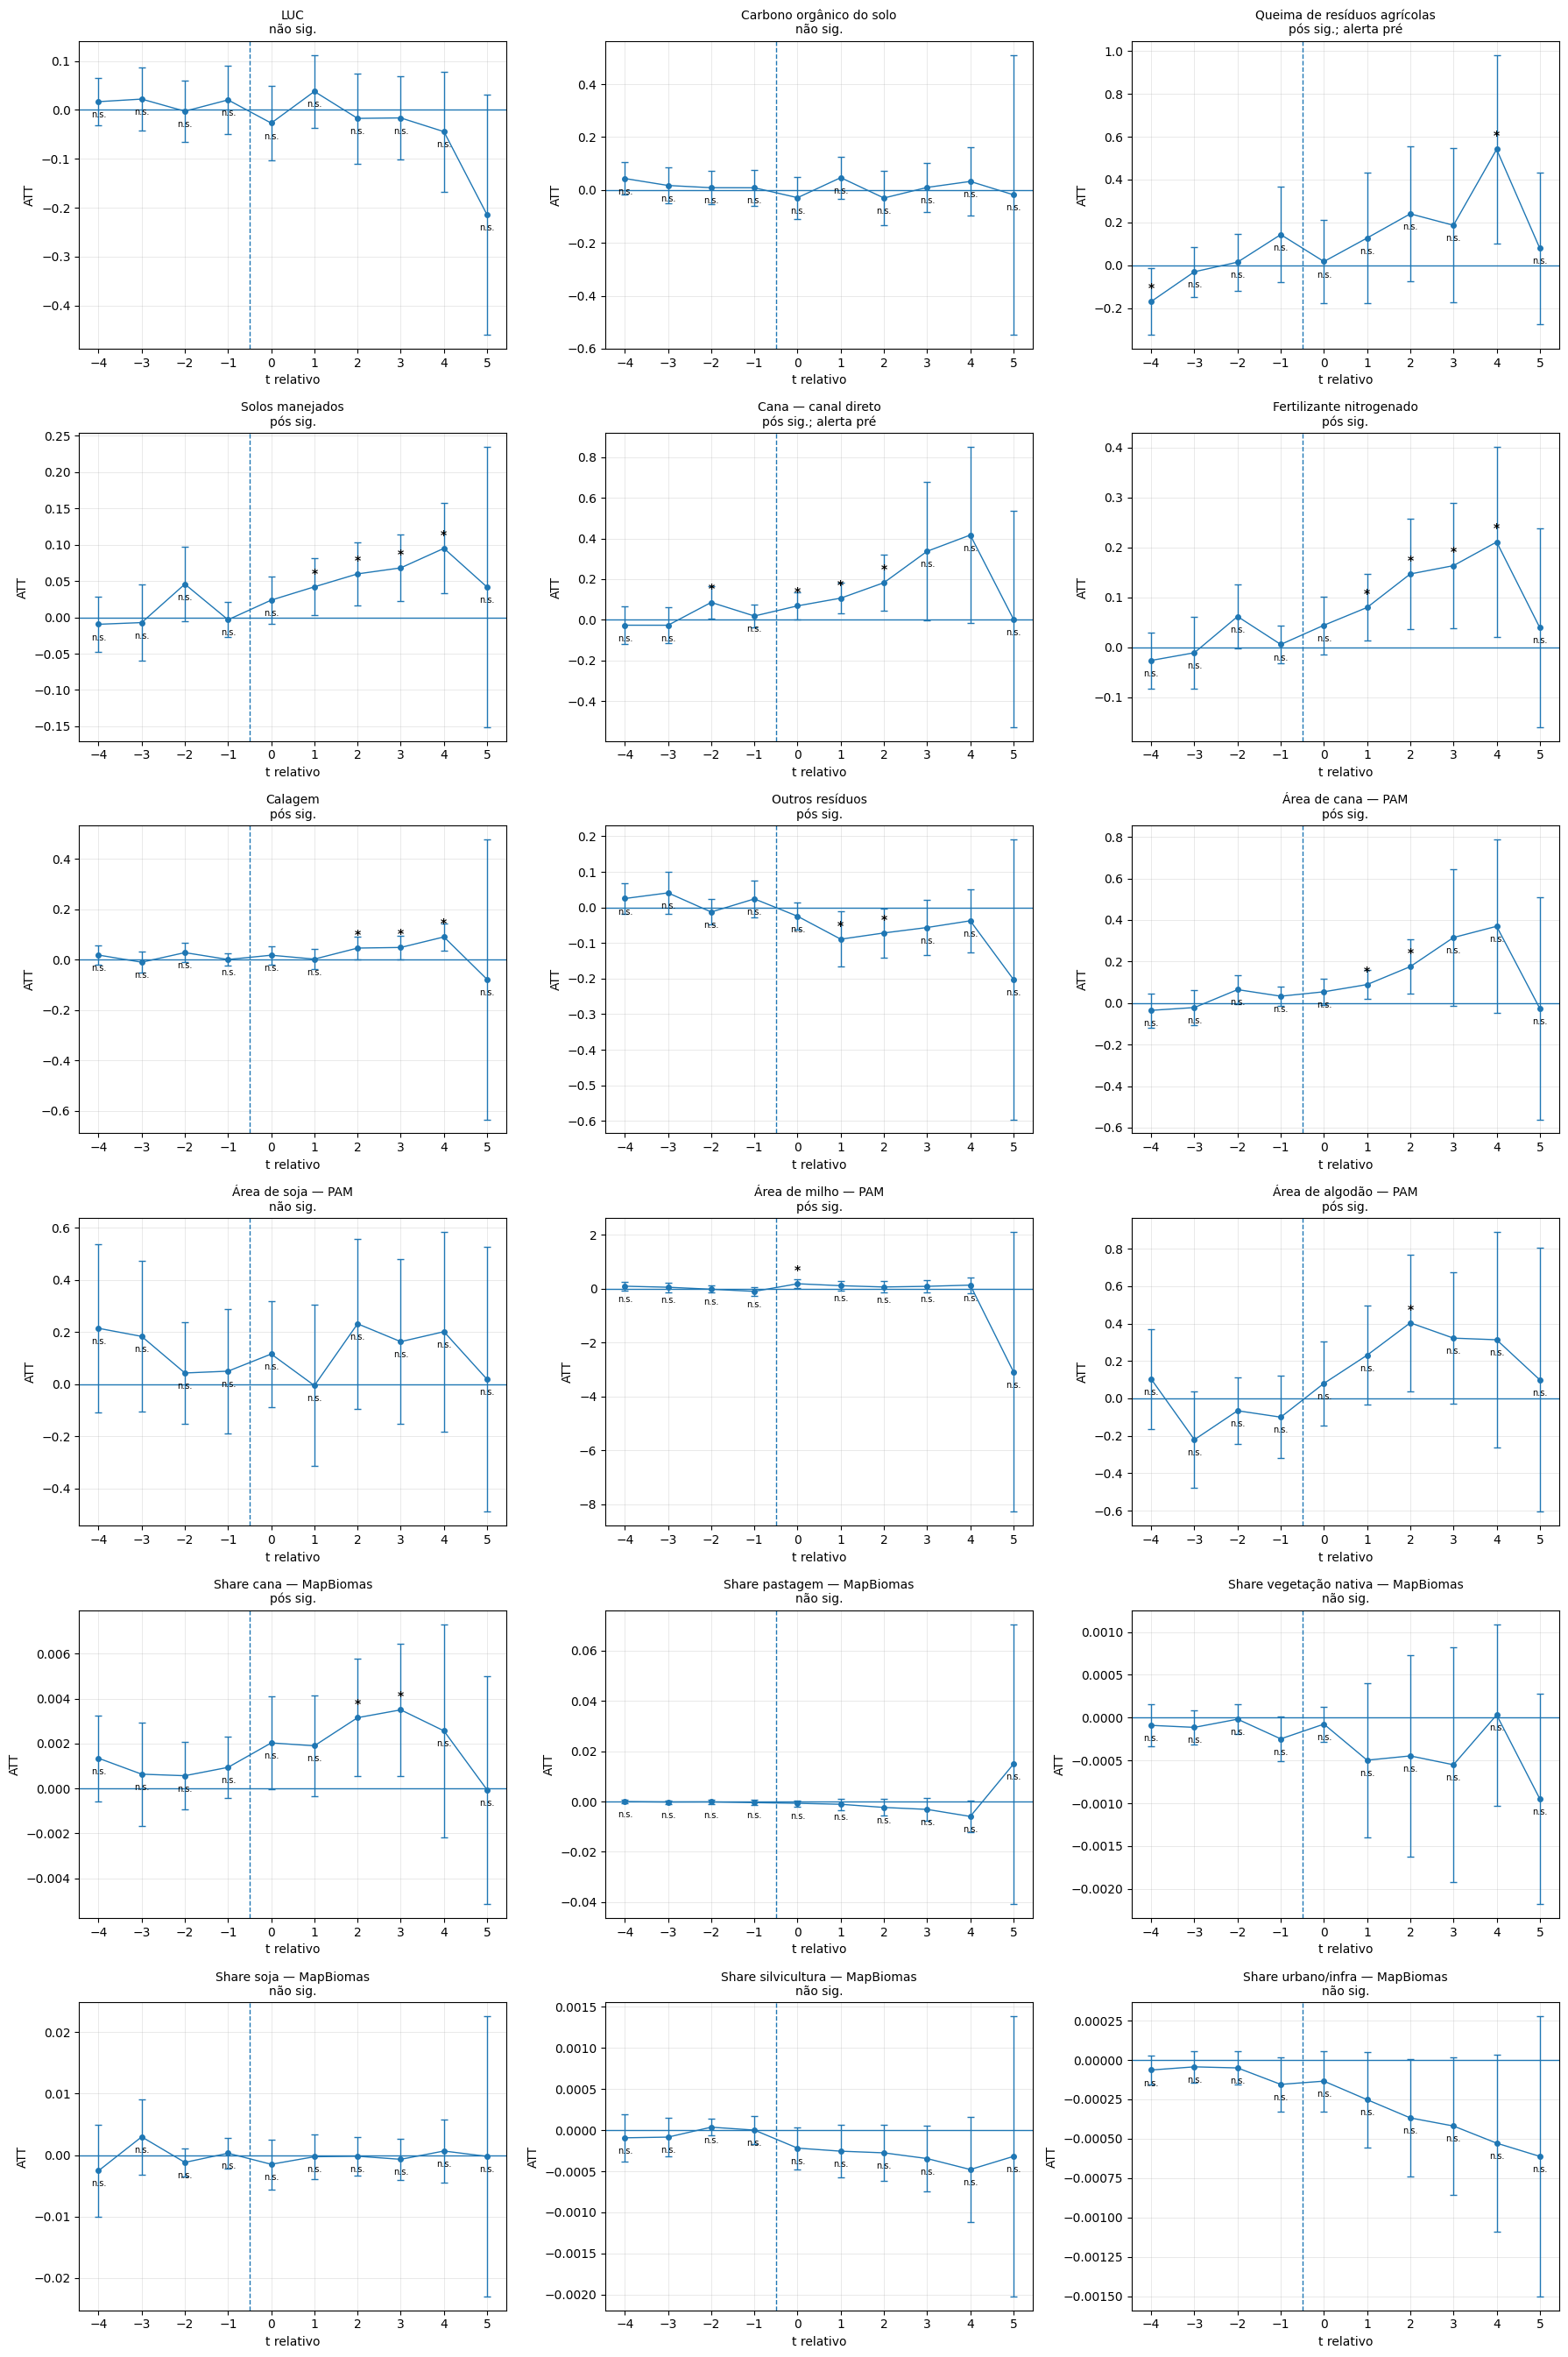

In [15]:
# ============================================================================
# PLOT EVENT STUDIES — 18 outcomes
# Sinaliza pontos significativos (*) e não significativos (n.s.)
# ============================================================================

import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ----------------------------------------------------------------------------
# 1. Carregar event_df, caso ainda não esteja na memória
# ----------------------------------------------------------------------------

if "event_df" not in globals():
    possible_paths = [
        "event_study_consolidado.csv",
        "/content/event_study_consolidado.csv",
        BASE_DIR / "outputs" / "tables" / "event_study_consolidado.csv",
    ]

    event_df = None
    for p in possible_paths:
        if os.path.exists(p):
            event_df = pd.read_csv(p)
            print(f"OK: event_df carregado de {p}")
            break

    if event_df is None:
        raise FileNotFoundError(
            "Não encontrei event_df na memória nem event_study_consolidado.csv nos caminhos padrão."
        )

# ----------------------------------------------------------------------------
# 2. Padronizar colunas
# ----------------------------------------------------------------------------

df = event_df.copy()

rename_candidates = {
    "relative_period": "event_time",
    "period": "event_time",
    "std_error": "SE",
    "se": "SE",
    "lower": "CI_lo",
    "upper": "CI_hi",
    "ci_lo": "CI_lo",
    "ci_hi": "CI_hi",
}

df = df.rename(columns={c: rename_candidates.get(c, c) for c in df.columns})

required_cols = ["outcome", "event_time", "ATT", "SE", "CI_lo", "CI_hi"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Colunas ausentes em event_df: {missing}")

for c in ["event_time", "ATT", "SE", "CI_lo", "CI_hi"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["outcome", "event_time", "ATT", "SE", "CI_lo", "CI_hi"])

# Significância: intervalo de confiança não cruza zero
df["sig_5pct"] = (df["CI_lo"] > 0) | (df["CI_hi"] < 0)
df["post_period"] = df["event_time"] >= 0

# ----------------------------------------------------------------------------
# 3. Labels mais legíveis
# ----------------------------------------------------------------------------

outcome_labels = {
    "asinh_luc": "LUC",
    "asinh_carbono_solo": "Carbono orgânico do solo",
    "log1p_queima": "Queima de resíduos agrícolas",
    "log_solos_manejados": "Solos manejados",
    "asinh_cana_direto": "Cana — canal direto",
    "log1p_fert_n": "Fertilizante nitrogenado",
    "log1p_calagem": "Calagem",
    "log1p_res_outros": "Outros resíduos",
    "log1p_pam_area_cana_t": "Área de cana — PAM",
    "asinh_pam_area_soja_t": "Área de soja — PAM",
    "asinh_pam_area_milho_t": "Área de milho — PAM",
    "asinh_pam_area_algodao_t": "Área de algodão — PAM",
    "log1p_share_cana_mapb": "Share cana — MapBiomas",
    "log1p_share_pastagem_mapb": "Share pastagem — MapBiomas",
    "log1p_share_vegetacao_nativa_mapb": "Share vegetação nativa — MapBiomas",
    "asinh_share_soja_mapb": "Share soja — MapBiomas",
    "asinh_share_silvicultura_mapb": "Share silvicultura — MapBiomas",
    "asinh_share_urbano_infra_mapb": "Share urbano/infra — MapBiomas",
}

group_map = {
    "asinh_luc": "G1 Macro-canais",
    "asinh_carbono_solo": "G1 Macro-canais",
    "log1p_queima": "G1 Macro-canais",
    "log_solos_manejados": "G1 Macro-canais",

    "asinh_cana_direto": "G2 Decomposição",
    "log1p_fert_n": "G2 Decomposição",
    "log1p_calagem": "G2 Decomposição",
    "log1p_res_outros": "G2 Decomposição",

    "log1p_pam_area_cana_t": "G3 Substituição PAM",
    "asinh_pam_area_soja_t": "G3 Substituição PAM",
    "asinh_pam_area_milho_t": "G3 Substituição PAM",
    "asinh_pam_area_algodao_t": "G3 Substituição PAM",

    "log1p_share_cana_mapb": "G4 MapBiomas",
    "log1p_share_pastagem_mapb": "G4 MapBiomas",
    "log1p_share_vegetacao_nativa_mapb": "G4 MapBiomas",
    "asinh_share_soja_mapb": "G4 MapBiomas",
    "asinh_share_silvicultura_mapb": "G4 MapBiomas",
    "asinh_share_urbano_infra_mapb": "G4 MapBiomas",
}

# ----------------------------------------------------------------------------
# 4. Função de plot individual
# ----------------------------------------------------------------------------

def safe_filename(text):
    text = re.sub(r"[^\w\-_\. ]", "_", str(text))
    text = text.replace(" ", "_")
    return text


def plot_event_study_one(sub, outcome, save_path=None):
    sub = sub.sort_values("event_time").copy()

    label = outcome_labels.get(outcome, outcome)
    group = group_map.get(outcome, "")

    post_sig = sub.loc[sub["post_period"], "sig_5pct"].any()
    pre_sig = sub.loc[sub["event_time"] < 0, "sig_5pct"].any()

    fig, ax = plt.subplots(figsize=(8, 5))

    # Linha de zero e linha do tratamento
    ax.axhline(0, linewidth=1)
    ax.axvline(-0.5, linestyle="--", linewidth=1)

    # Intervalo de confiança
    yerr = np.vstack([
        sub["ATT"] - sub["CI_lo"],
        sub["CI_hi"] - sub["ATT"]
    ])

    ax.errorbar(
        sub["event_time"],
        sub["ATT"],
        yerr=yerr,
        fmt="o-",
        capsize=4,
        linewidth=1.5,
        markersize=5,
        label="ATT com IC 95%"
    )

    # Marcar pontos significativos e não significativos
    for _, row in sub.iterrows():
        x = row["event_time"]
        y = row["ATT"]

        if row["sig_5pct"]:
            ax.annotate(
                "*",
                xy=(x, y),
                xytext=(0, 10),
                textcoords="offset points",
                ha="center",
                fontsize=12,
                fontweight="bold"
            )
        else:
            ax.annotate(
                "n.s.",
                xy=(x, y),
                xytext=(0, -16),
                textcoords="offset points",
                ha="center",
                fontsize=8
            )

    # Título com diagnóstico
    if post_sig and not pre_sig:
        status = "efeito pós-tratamento significativo; pre-trends sem alerta"
    elif post_sig and pre_sig:
        status = "efeito pós-tratamento significativo, mas com alerta de pre-trend"
    elif not post_sig and pre_sig:
        status = "sem efeito pós robusto; alerta de pre-trend"
    else:
        status = "sem efeito pós-tratamento significativo"

    title = f"{label}\n{group} — {status}" if group else f"{label}\n{status}"

    ax.set_title(title)
    ax.set_xlabel("Tempo relativo ao tratamento")
    ax.set_ylabel("ATT")
    ax.set_xticks(sorted(sub["event_time"].unique()))
    ax.grid(True, linewidth=0.5, alpha=0.4)

    # Legenda explicativa
    ax.text(
        0.01,
        0.01,
        "* = IC 95% não cruza zero | n.s. = não significativo",
        transform=ax.transAxes,
        fontsize=8,
        va="bottom"
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax


# ----------------------------------------------------------------------------
# 5. Gerar todos os gráficos individuais
# ----------------------------------------------------------------------------

out_dir = "event_study_plots"
os.makedirs(out_dir, exist_ok=True)

outcomes_order = list(group_map.keys())
remaining = [o for o in df["outcome"].unique() if o not in outcomes_order]
outcomes_order = [o for o in outcomes_order if o in df["outcome"].unique()] + remaining

pdf_path = os.path.join(out_dir, "event_studies_todos_outcomes.pdf")

summary_rows = []

with PdfPages(pdf_path) as pdf:
    for outcome in outcomes_order:
        sub = df[df["outcome"] == outcome].copy()

        fig_path = os.path.join(out_dir, f"event_study_{safe_filename(outcome)}.png")

        fig, ax = plot_event_study_one(
            sub=sub,
            outcome=outcome,
            save_path=fig_path
        )

        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        post_sig = sub.loc[sub["event_time"] >= 0, "sig_5pct"].any()
        pre_sig = sub.loc[sub["event_time"] < 0, "sig_5pct"].any()

        summary_rows.append({
            "outcome": outcome,
            "label": outcome_labels.get(outcome, outcome),
            "group": group_map.get(outcome, ""),
            "n_periods": len(sub),
            "n_sig_total": int(sub["sig_5pct"].sum()),
            "n_sig_pre": int(sub.loc[sub["event_time"] < 0, "sig_5pct"].sum()),
            "n_sig_post": int(sub.loc[sub["event_time"] >= 0, "sig_5pct"].sum()),
            "has_post_sig": post_sig,
            "has_pretrend_alert": pre_sig,
            "plot_path": fig_path,
        })

plot_summary = pd.DataFrame(summary_rows)

summary_path = os.path.join(out_dir, "event_study_plot_summary.csv")
plot_summary.to_csv(summary_path, index=False)

print("=" * 90)
print("GRÁFICOS GERADOS")
print("=" * 90)
print(f"PNG individuais salvos em: {out_dir}/")
print(f"PDF consolidado salvo em: {pdf_path}")
print(f"Resumo salvo em: {summary_path}")

display(plot_summary)

# ----------------------------------------------------------------------------
# 6. Mostrar também uma grade rápida no notebook
# ----------------------------------------------------------------------------

n = len(outcomes_order)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, outcome in zip(axes, outcomes_order):
    sub = df[df["outcome"] == outcome].sort_values("event_time").copy()

    yerr = np.vstack([
        sub["ATT"] - sub["CI_lo"],
        sub["CI_hi"] - sub["ATT"]
    ])

    ax.axhline(0, linewidth=1)
    ax.axvline(-0.5, linestyle="--", linewidth=1)

    ax.errorbar(
        sub["event_time"],
        sub["ATT"],
        yerr=yerr,
        fmt="o-",
        capsize=3,
        linewidth=1,
        markersize=4
    )

    for _, row in sub.iterrows():
        marker = "*" if row["sig_5pct"] else "n.s."
        offset = 8 if row["sig_5pct"] else -13
        size = 10 if row["sig_5pct"] else 7
        weight = "bold" if row["sig_5pct"] else "normal"

        ax.annotate(
            marker,
            xy=(row["event_time"], row["ATT"]),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            fontsize=size,
            fontweight=weight
        )

    label = outcome_labels.get(outcome, outcome)
    post_sig = sub.loc[sub["event_time"] >= 0, "sig_5pct"].any()
    pre_sig = sub.loc[sub["event_time"] < 0, "sig_5pct"].any()

    if post_sig and pre_sig:
        suffix = "pós sig.; alerta pré"
    elif post_sig:
        suffix = "pós sig."
    elif pre_sig:
        suffix = "alerta pré"
    else:
        suffix = "não sig."

    ax.set_title(f"{label}\n{suffix}", fontsize=10)
    ax.set_xlabel("t relativo")
    ax.set_ylabel("ATT")
    ax.set_xticks(sorted(sub["event_time"].unique()))
    ax.grid(True, linewidth=0.5, alpha=0.4)

for ax in axes[len(outcomes_order):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================================
# INVESTIGAÇÃO DETALHADA — cana_direto e queima (pre-trends violados)
# Cole após o Bloco 6 do 11f, depois que ev_df está em memória.
# Roda mais 4 análises sem custo CS-DR adicional (reusa estimações já feitas).
# Adicional: 1 chamada ATTgt para aggregate('group') por outcome (~10s cada).
# ============================================================================
import numpy as np
import pandas as pd
from differences import ATTgt

OUTCOMES_SUSPEITOS = ["asinh_cana_direto", "log1p_queima"]

# =====================================================================
# 1. Forma do pre-trend (sinal de cada período individual)
# =====================================================================
print("=" * 88)
print("INVESTIGACAO 1 — Forma do pre-trend (sinal e magnitude por periodo)")
print("=" * 88)
print(f"{'outcome':<22}{'t=-4':>10}{'t=-3':>10}{'t=-2':>10}{'t=-1':>10}  | leitura")
print("-" * 88)
for outc in OUTCOMES_SUSPEITOS:
    sub = ev_df[ev_df["outcome"] == outc].sort_values("event_time")
    pre = sub[sub["event_time"].between(-4, -1)]

    def cell(t):
        x = pre[pre["event_time"] == t]
        if x.empty:
            return "      ---"
        att = float(x.iloc[0]["ATT"])
        se = float(x.iloc[0]["SE"]) if pd.notna(x.iloc[0]["SE"]) else np.nan
        sig = (np.isfinite(se) and se > 0 and abs(att / se) > 1.96)
        return f"{att:+.4f}{'*' if sig else ' '}"

    # Diagnóstico de forma
    pre_vals = [float(pre[pre["event_time"] == t].iloc[0]["ATT"])
                for t in [-4, -3, -2] if not pre[pre["event_time"] == t].empty]
    if len(pre_vals) >= 3:
        # Monotônico crescente?
        cresc = pre_vals[0] < pre_vals[1] < pre_vals[2]
        # Monotônico decrescente?
        decr = pre_vals[0] > pre_vals[1] > pre_vals[2]
        # Acelerando (crescimento acumulado positivo)?
        if cresc and pre_vals[2] > 0:
            forma = "ACELERANDO (vies sel. classico)"
        elif decr and pre_vals[2] < 0:
            forma = "DESACELERANDO (anti-vies)"
        elif cresc and pre_vals[2] < 0:
            forma = "Convergindo p/ zero (saudavel)"
        elif decr and pre_vals[2] > 0:
            forma = "Convergindo p/ zero (saudavel)"
        else:
            forma = "Erratico (ruido)"
    else:
        forma = "Periodos insuficientes"

    print(f"{outc:<22}{cell(-4):>10}{cell(-3):>10}{cell(-2):>10}{cell(-1):>10}  | {forma}")

# =====================================================================
# 2. Event-study completo (todos os 10 períodos t=-4 a +5)
# =====================================================================
print()
print("=" * 88)
print("INVESTIGACAO 2 — Event-study completo (t=-4 a +5)")
print("=" * 88)
for outc in OUTCOMES_SUSPEITOS:
    print(f"\n>>> {outc}")
    sub = ev_df[ev_df["outcome"] == outc].sort_values("event_time")
    print(f"{'t':>5}{'ATT':>10}{'SE':>10}{'|z|':>8}{'CI_lo':>10}{'CI_hi':>10}  sig")
    print("-" * 60)
    for _, r in sub.iterrows():
        att = float(r["ATT"]) if pd.notna(r["ATT"]) else np.nan
        se = float(r["SE"]) if pd.notna(r["SE"]) else np.nan
        z = abs(att / se) if (np.isfinite(se) and se > 0) else np.nan
        sig = "  *" if (np.isfinite(z) and z > 1.96) else ""
        ci_lo = float(r.get("CI_lo", np.nan)) if pd.notna(r.get("CI_lo")) else np.nan
        ci_hi = float(r.get("CI_hi", np.nan)) if pd.notna(r.get("CI_hi")) else np.nan
        print(f"{int(r['event_time']):>5}{att:>+10.4f}{se:>10.4f}{z:>8.2f}"
              f"{ci_lo:>+10.4f}{ci_hi:>+10.4f}{sig}")

# =====================================================================
# 3. Heterogeneidade por coorte (aggregate 'group')
# =====================================================================
print()
print("=" * 88)
print("INVESTIGACAO 3 — Heterogeneidade por coorte (g = ano de tratamento)")
print("=" * 88)
print("Roda ATTgt + aggregate('group') por outcome (1 chamada cada, ~10s)")

for outc in OUTCOMES_SUSPEITOS:
    print(f"\n>>> {outc}")
    try:
        data = (panel_cs.dropna(subset=[outc])
                .set_index(["geocode", "ano"]).sort_index())
        attgt = ATTgt(data=data, cohort_column="g_m_cs")
        attgt.fit(
            formula=f"{outc} ~ " + " + ".join(COVS_FULL2),
            est_method="dr",
            control_group="never_treated",
            boot_iterations=999,
            random_state=42,
            progress_bar=False,
            n_jobs=1,
        )
        grp_agg = attgt.aggregate("group")
        # Achatar (mesma lógica do hotfix)
        grp_flat = bes._flatten_event_result(grp_agg)
        # Renomear primeira coluna para 'group'
        grp_flat = grp_flat.rename(columns={"event_time": "group"})
        print(f"{'cohort':>8}{'ATT':>10}{'SE':>10}{'|z|':>8}{'CI_lo':>10}{'CI_hi':>10}  sig")
        print("-" * 60)
        for _, r in grp_flat.iterrows():
            att = float(r["ATT"]) if pd.notna(r["ATT"]) else np.nan
            se = float(r["SE"]) if pd.notna(r["SE"]) else np.nan
            z = abs(att / se) if (np.isfinite(se) and se > 0) else np.nan
            sig = "  *" if (np.isfinite(z) and z > 1.96) else ""
            print(f"{int(r['group']):>8}{att:>+10.4f}{se:>10.4f}{z:>8.2f}"
                  f"{float(r.get('CI_lo', np.nan)):>+10.4f}"
                  f"{float(r.get('CI_hi', np.nan)):>+10.4f}{sig}")
    except Exception as e:
        print(f"  FALHOU: {type(e).__name__}: {str(e)[:120]}")

# =====================================================================
# 4. n por coorte e horizonte (quantos munis em cada g x t)
# =====================================================================
print()
print("=" * 88)
print("INVESTIGACAO 4 — n municipios por coorte e horizonte")
print("=" * 88)
# Contagem de municipios tratados por g_m_cs
cohorts = panel_cs.groupby("g_m_cs")["geocode"].nunique() // 10  # /10 anos
cohorts = cohorts[cohorts.index.notna()]
print(f"\nMunicipios por coorte de tratamento:")
print(cohorts.to_string())
print(f"\nTotal tratados: {int(cohorts.sum())}")

# Quantos anos pos-tratamento cada coorte tem disponivel
print(f"\nAnos pos-tratamento disponiveis (ate ano max = 2024):")
for g in sorted(cohorts.index):
    g_int = int(g)
    n_post = 2024 - g_int + 1  # incluindo o ano de tratamento
    n_munis = int(cohorts[g])
    print(f"  g={g_int}: {n_munis} munis, observados em t=0 a t={n_post-1} "
          f"(t=+5 disponivel: {'SIM' if n_post > 5 else 'NAO'})")

print()
print("=" * 88)
print("CONCLUSAO da investigacao — leitura combinada")
print("=" * 88)
print("Para cada outcome, sintetiza:")
print("1. A forma do pre-trend ajuda a decidir se 'violado' = vies real ou anti-vies")
print("2. O event-study completo mostra a trajetoria do efeito ao longo do tempo")
print("3. Por coorte, vemos se 1-2 coortes dominam o sinal")
print("4. n por horizonte mostra se ATTs em t=+4,+5 sao baseados em poucos munis")

INVESTIGACAO 1 — Forma do pre-trend (sinal e magnitude por periodo)
outcome                     t=-4      t=-3      t=-2      t=-1  | leitura
----------------------------------------------------------------------------------------
asinh_cana_direto       -0.0264   -0.0266   +0.0857*  +0.0188   | Erratico (ruido)
log1p_queima            -0.1688*  -0.0301   +0.0148   +0.1435   | ACELERANDO (vies sel. classico)

INVESTIGACAO 2 — Event-study completo (t=-4 a +5)

>>> asinh_cana_direto
    t       ATT        SE     |z|     CI_lo     CI_hi  sig
------------------------------------------------------------
   -4   -0.0264    0.0473    0.56   -0.1192   +0.0663
   -3   -0.0266    0.0447    0.60   -0.1141   +0.0610
   -2   +0.0857    0.0406    2.11   +0.0060   +0.1653  *
   -1   +0.0188    0.0278    0.68   -0.0357   +0.0732
    0   +0.0687    0.0343    2.01   +0.0016   +0.1358  *
    1   +0.1066    0.0378    2.82   +0.0324   +0.1808  *
    2   +0.1825    0.0693    2.63   +0.0467   +0.3184  *
    

In [17]:
# ============================================================================
# INVESTIGAÇÃO 4 (CORRIGIDA) — n municípios por coorte e horizonte
# Cole no notebook depois da célula anterior — corrige o bug do //10
# ============================================================================
import pandas as pd

# Contagem CORRIGIDA: pegar uma linha por município (não dividir por 10)
muni_cohorts = (
    panel_cs[panel_cs["g_m_cs"].notna()]
    .groupby("geocode")["g_m_cs"]
    .first()
)
cohorts = muni_cohorts.value_counts().sort_index()

print("=" * 88)
print("INVESTIGACAO 4 (corrigida) — n municipios por coorte de tratamento")
print("=" * 88)
print(f"\nMunicipios por coorte (g_m_cs = ano de tratamento):")
print(cohorts.to_string())
print(f"\nTotal tratados: {int(cohorts.sum())}  (esperado: 194)")

print(f"\nHorizontes pos-tratamento disponiveis por coorte (ate 2024):")
print(f"{'cohort':>8}{'n_munis':>10}{'horizontes disponiveis':>30}{'t=+5?':>10}")
print("-" * 60)
for g, n_munis in cohorts.items():
    g_int = int(g)
    n_post = 2024 - g_int  # 0, 1, ..., n_post (incluindo t=0)
    horizontes = f"t=0 a t=+{n_post}"
    t5_disp = "SIM" if n_post >= 5 else "NAO"
    print(f"{g_int:>8}{int(n_munis):>10}{horizontes:>30}{t5_disp:>10}")

print("\n" + "=" * 88)
print("INTERPRETACAO para ATT em t=+5:")
print("Soh as coortes com g <= 2019 contribuem (5 anos pos-trat).")
print(f"=> ATT(t=+5) e baseado em apenas {int(cohorts[cohorts.index <= 2019].sum())} municipios")
print(f"   ({int(cohorts.sum())} no total - coortes 2018, 2019)")
print("=" * 88)

INVESTIGACAO 4 (corrigida) — n municipios por coorte de tratamento

Municipios por coorte (g_m_cs = ano de tratamento):
g_m_cs
2019.0      2
2020.0    142
2021.0     40
2022.0      8
2023.0      2

Total tratados: 194  (esperado: 194)

Horizontes pos-tratamento disponiveis por coorte (ate 2024):
  cohort   n_munis        horizontes disponiveis     t=+5?
------------------------------------------------------------
    2019         2                    t=0 a t=+5       SIM
    2020       142                    t=0 a t=+4       NAO
    2021        40                    t=0 a t=+3       NAO
    2022         8                    t=0 a t=+2       NAO
    2023         2                    t=0 a t=+1       NAO

INTERPRETACAO para ATT em t=+5:
Soh as coortes com g <= 2019 contribuem (5 anos pos-trat).
=> ATT(t=+5) e baseado em apenas 2 municipios
   (194 no total - coortes 2018, 2019)
